In [129]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
import random

# Problem 4

In [127]:
def system_A(c=3, lam=6, mu=3, T=1000):

    state_times = [[] for _ in range(c)]

    for queue in range(c):
        t = 0
        Q_t = 0
        events = []

        heapq.heappush(events, (np.random.exponential(1/(lam/c)), 'arrival'))

        while events and events[0][0] < T:
            t, event_type = heapq.heappop(events)

            state_times[queue].append((t, Q_t))

            if event_type == 'arrival':
                if Q_t == 0:
                    heapq.heappush(events, (t + np.random.exponential(1/mu), 'departure'))
                Q_t += 1
                heapq.heappush(events, (t + np.random.exponential(1/(lam/c)), 'arrival'))
            elif event_type == 'departure':
                Q_t -= 1
                if Q_t >= 1:
                    heapq.heappush(events, (t + np.random.exponential(1/mu), 'departure'))




    all_state_times = []
    for queue_idx in range(len(state_times)): # loop through each queue
        for t, q in state_times[queue_idx]: # for each tuple
            all_state_times.append((t, queue_idx, q)) # add the tuple to combined list

    all_state_times.sort(key=lambda x: x[0])  # Sort combined list by time

    Q_current = [0] * c
    combined_state_times = []

    for t, queue_idx, q in all_state_times: # loop through combined list (now sorted by time)
        Q_current[queue_idx] = q # some queue has changed, update the current state of that queue
        Q_total = sum(Q_current) # take new sum
        combined_state_times.append((t, Q_total)) # add to final list


    return combined_state_times


def system_B(c=3, lam=6, mu=3, T=1000):

    t = 0
    Q_t = 0
    events = []
    state_times = []

    heapq.heappush(events, (np.random.exponential(1/lam), 'arrival'))

    while events and events[0][0] < T:
        t, event_type = heapq.heappop(events)

        state_times.append((t, Q_t))

        if event_type == 'arrival':
            if Q_t == 0: # If the system is empty, schedule a departure for the new customer (served immediately)
                heapq.heappush(events, (t + np.random.exponential(1/(c*mu)), 'departure'))
            Q_t += 1
            heapq.heappush(events, (t + np.random.exponential(1/lam), 'arrival')) # Schedule the next arrival
        elif event_type == 'departure':
            Q_t -= 1
            if Q_t >= 1: # If there are still customers in the system, schedule the next departure (next customer enters service)
                heapq.heappush(events, (t + np.random.exponential(1/(c*mu)), 'departure'))

    return state_times

def system_C(c=3, lam=6, mu=3, T=1000):

    t = 0
    Q_t = 0
    events = []
    state_times = []

    heapq.heappush(events, (np.random.exponential(1/lam), 'arrival'))

    while events and events[0][0] < T:
        t, event_type = heapq.heappop(events)

        state_times.append((t, Q_t))

        if event_type == 'arrival':
            if Q_t < c: # If customer can be served immediately
                heapq.heappush(events, (t + np.random.exponential(1/mu), 'departure'))
            Q_t += 1
            heapq.heappush(events, (t + np.random.exponential(1/lam), 'arrival'))
        elif event_type == 'departure':
            Q_t -= 1
            if Q_t >= c: # If there are more customers than servers, schedule the next departure (next customer enters service)
                heapq.heappush(events, (t + np.random.exponential(1/mu), 'departure'))

    return state_times

## a), b)

Estimated distribution for System A: {0: 0.0018727575162475077, 1: 0.027254812132922725, 2: 0.08663520882105641, 3: 0.13864704099476732, 4: 0.11541264619097288, 5: 0.10438436884685555, 6: 0.10032835431271259, 7: 0.08732787578761969, 8: 0.07291953955605107, 9: 0.0616467355857496, 10: 0.04242945753736076, 11: 0.027581727256691013, 12: 0.019334044302934294, 13: 0.016930472010187266, 14: 0.014066619603906688, 15: 0.017279588601564255, 16: 0.01440490776009876, 17: 0.012197377088531367, 18: 0.00851431692760535, 19: 0.007461248640582012, 20: 0.005479796133216659, 21: 0.004390766605535974, 22: 0.003751153166146524, 23: 0.0021799109413379717, 24: 0.0017988982204488163, 25: 0.001201240628944799, 26: 0.001396959179022254, 27: 0.0012579431703782366, 28: 0.001070833282318477, 29: 0.0005961921411231491, 30: 3.136577012172769e-05, 31: 0.00010563691908186879, 32: 0.00011020436790613082}
Estimated distribution for System B: {0: 0.13661034372386469, 1: 0.42562312833678617, 2: 0.1459941983224081, 3: 0.09

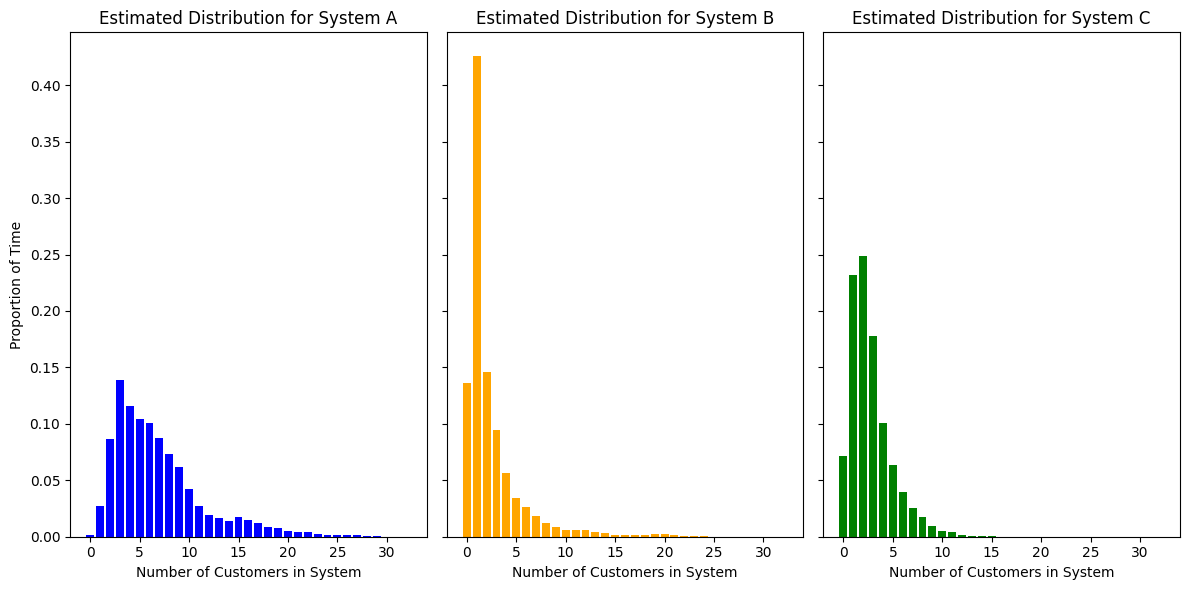

In [128]:
def estimate_distributions(state_times, T=1000):
    time_in_state = {}

    for i in range(len(state_times) - 1):
        t, Q = state_times[i]
        next_t, _ = state_times[i + 1]

        time = next_t - t

        if Q not in time_in_state:
            time_in_state[Q] = 0
        time_in_state[Q] += time

    last_t, last_Q = state_times[-1]
    if last_Q not in time_in_state:
        time_in_state[last_Q] = 0
    time_in_state[last_Q] += T - last_t

    total_time = sum(time_in_state.values())
    distribution = {Q: time / total_time for Q, time in time_in_state.items()}

    return distribution

a = system_A()
estimate_distributions_A = estimate_distributions(a)
print("Estimated distribution for System A:", estimate_distributions_A)

b = system_B()
estimate_distributions_B = estimate_distributions(b)
print("Estimated distribution for System B:", estimate_distributions_B)

c = system_C()
estimate_distributions_C = estimate_distributions(c)
print("Estimated distribution for System C:", estimate_distributions_C)


# Create subplots with shared y-axis
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharex=True, sharey=True)

# Plot System A
axes[0].bar(estimate_distributions_A.keys(), estimate_distributions_A.values(), color='blue')
axes[0].set_title('Estimated Distribution for System A')
axes[0].set_xlabel('Number of Customers in System')
axes[0].set_ylabel('Proportion of Time')

# Plot System B
axes[1].bar(estimate_distributions_B.keys(), estimate_distributions_B.values(), color='orange')
axes[1].set_title('Estimated Distribution for System B')
axes[1].set_xlabel('Number of Customers in System')

# Plot System C
axes[2].bar(estimate_distributions_C.keys(), estimate_distributions_C.values(), color='green')
axes[2].set_title('Estimated Distribution for System C')
axes[2].set_xlabel('Number of Customers in System')

# Adjust layout
plt.tight_layout()
plt.show()

## c)
The best system in terms of congestion appears to be System B or C, which has more than 1 customer the least amount of time. System B has small fractions of time in high volumes of customers that add up to higher levels than System C.

## d)

In [109]:
def system_A_makespan(c=3, lam=6, mu=3, n_customers=100):
    t = 0
    Q = [0] * c
    events = []
    departure_count = 0

    heapq.heappush(events, (np.random.exponential(1/lam), 'arrival', None)) # Schedule first arrival without queue index since not yet assigned

    while departure_count < n_customers:
        t, event_type, queue_idx = heapq.heappop(events)

        if event_type == 'arrival':
            queue_idx = np.random.randint(0, c) # Randomly assign arriving customer to one of the c queues

            if Q[queue_idx] == 0:
                heapq.heappush(events, (t + np.random.exponential(1/mu), 'departure', queue_idx))
            Q[queue_idx] += 1
            heapq.heappush(events, (t + np.random.exponential(1/lam), 'arrival', None)) # Schedule next arrival without queue index since not yet assigned

        elif event_type == 'departure':
            departure_count += 1
            Q[queue_idx] -= 1
            if Q[queue_idx] >= 1:
                heapq.heappush(events, (t + np.random.exponential(1/mu), 'departure', queue_idx))

    return t

def system_B_makespan(c=3, lam=6, mu=3, n_customers=100):
    t = 0
    Q_t = 0
    events = []
    departure_count = 0

    heapq.heappush(events, (np.random.exponential(1/lam), 'arrival'))

    while departure_count < n_customers:
        t, event_type = heapq.heappop(events)

        if event_type == 'arrival':
            if Q_t == 0: # If the system is empty, schedule a departure for the new customer (served immediately)
                heapq.heappush(events, (t + np.random.exponential(1/(c*mu)), 'departure'))
            Q_t += 1
            heapq.heappush(events, (t + np.random.exponential(1/lam), 'arrival')) # Schedule the next arrival
        elif event_type == 'departure':
            departure_count += 1
            Q_t -= 1
            if Q_t >= 1: # If there are still customers in the system, schedule the next departure (next customer enters service)
                heapq.heappush(events, (t + np.random.exponential(1/(c*mu)), 'departure'))

    return t

def system_C_makespan(c=3, lam=6, mu=3, n_customers=100):

    t = 0
    Q_t = 0
    events = []
    departure_count = 0

    heapq.heappush(events, (np.random.exponential(1/lam), 'arrival'))

    while departure_count < n_customers:
        t, event_type = heapq.heappop(events)

        if event_type == 'arrival':
            if Q_t < c: # If customer can be served immediately
                heapq.heappush(events, (t + np.random.exponential(1/mu), 'departure'))
            Q_t += 1
            heapq.heappush(events, (t + np.random.exponential(1/lam), 'arrival'))
        elif event_type == 'departure':
            departure_count += 1
            Q_t -= 1
            if Q_t >= c: # If there are more customers than servers, schedule the next departure (next customer enters service)
                heapq.heappush(events, (t + np.random.exponential(1/mu), 'departure'))

    return t

## e)

Avg Makespan for System A: 17.644061972357733
Avg Makespan for System B: 16.960879063767408
Avg Makespan for System C: 17.123518592058815


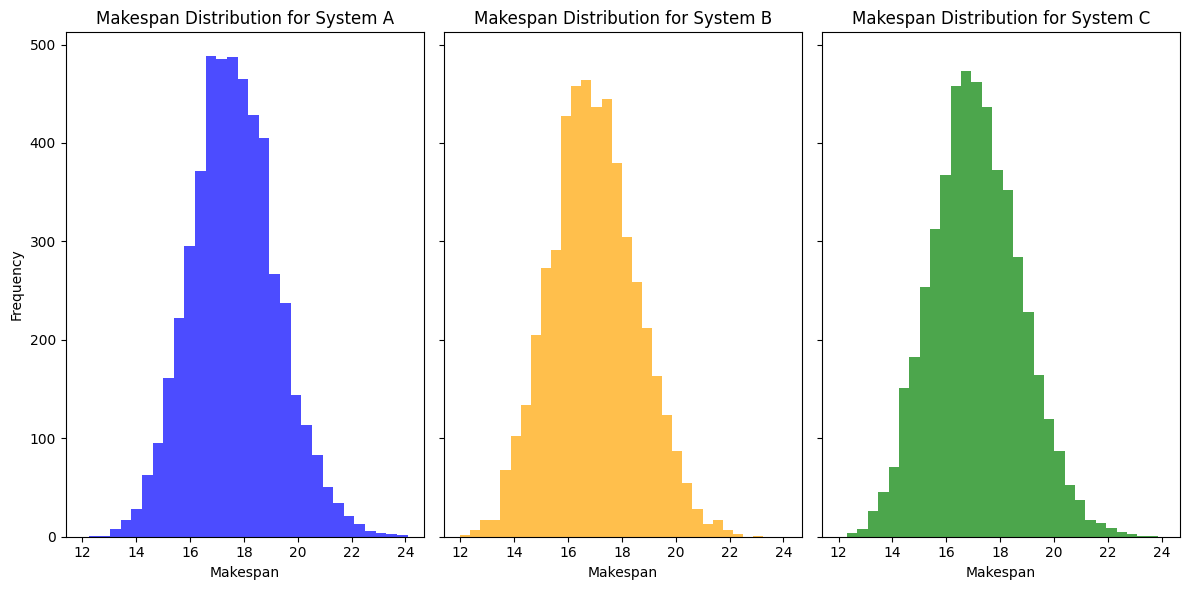

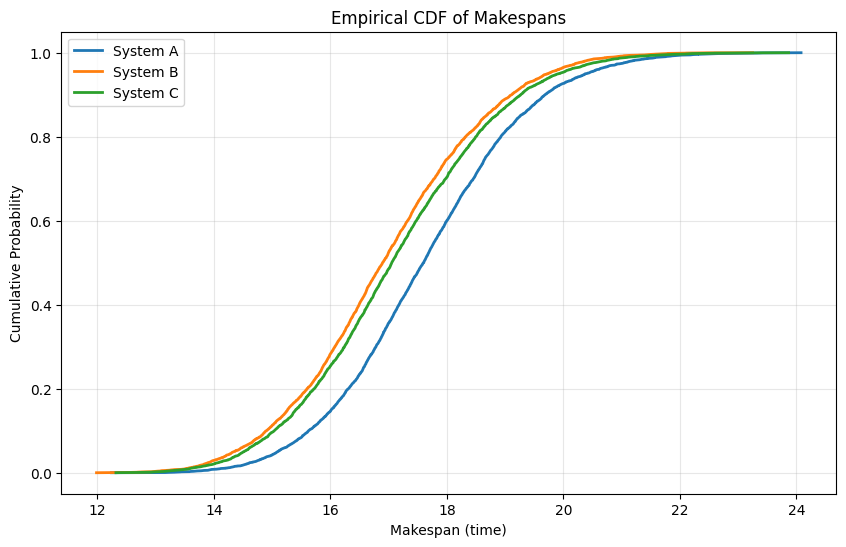

In [126]:
n_sims = 5000
a_makespans = [system_A_makespan() for _ in range(n_sims)]
print("Avg Makespan for System A:", np.mean(a_makespans))
b_makespans = [system_B_makespan() for _ in range(n_sims)]
print("Avg Makespan for System B:", np.mean(b_makespans))
c_makespans = [system_C_makespan() for _ in range(n_sims)]
print("Avg Makespan for System C:", np.mean(c_makespans))

fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharex=True, sharey=True)
axes[0].hist(a_makespans, bins=30, color='blue', alpha=0.7)
axes[0].set_title('Makespan Distribution for System A')
axes[0].set_xlabel('Makespan')
axes[0].set_ylabel('Frequency')
axes[1].hist(b_makespans, bins=30, color='orange', alpha=0.7)
axes[1].set_title('Makespan Distribution for System B')
axes[1].set_xlabel('Makespan')
axes[2].hist(c_makespans, bins=30, color='green', alpha=0.7)
axes[2].set_title('Makespan Distribution for System C')
axes[2].set_xlabel('Makespan')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

for makespans, label in [(a_makespans, 'System A'), 
                          (b_makespans, 'System B'),
                          (c_makespans, 'System C')]:
    sorted_data = np.sort(makespans)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    plt.plot(sorted_data, cdf, label=label, linewidth=2)

plt.xlabel('Makespan (time)')
plt.ylabel('Cumulative Probability')
plt.title('Empirical CDF of Makespans')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## f)
System B is the best system in terms of makespan, as it has the lowest average makespan time among the systems and the CDF dominates the other two.


# Problem 5
## a)

In [130]:
def er_simulation(lam=4.5, T=1000):
    t = 0
    
    Q_N = 0
    Q_L = 0
    Q_X = 0
    Q_D = 0

    state_history_N = []
    state_history_L = []
    state_history_X = []
    state_history_D = []

    events = []

    heapq.heappush(events, (np.random.exponential(1/lam), 'arrival')) # first arrival

    while events and events[0][0] < T:
        t, event_type = heapq.heappop(events)

        state_history_N.append((t, Q_N)) # record all states before one changes
        state_history_L.append((t, Q_L))
        state_history_X.append((t, Q_X))
        state_history_D.append((t, Q_D))

        if event_type == 'arrival':
            if Q_N == 0:
                heapq.heappush(events, (t + np.random.exponential(1/10), 'leave nurse')) # nurse rate 10
            Q_N += 1
            heapq.heappush(events, (t + np.random.exponential(1/lam), 'arrival')) # schedule next arrival

        elif event_type == 'leave nurse':
            Q_N -= 1
            if Q_N >= 1:
                heapq.heappush(events, (t + np.random.exponential(1/10), 'leave nurse')) # schedule next nurse departure if there are more patients waiting

            p = random.random()
            if p < 0.5:
                next_station = 'doctor'
            elif p < 0.8: # 30 % chance
                next_station = 'lab'
            else: # 20% chance
                next_station = 'xray'

            
            if next_station == 'doctor':
                if Q_D == 0:
                    heapq.heappush(events, (t + np.random.exponential(1/12), 'leave doctor')) # doctor rate 12
                Q_D += 1
            elif next_station == 'lab':
                if Q_L == 0:
                    heapq.heappush(events, (t + np.random.exponential(1/20), 'leave lab')) # lab rate 20
                Q_L += 1
            else: # xray
                if Q_X == 0:
                    heapq.heappush(events, (t + np.random.exponential(1/25), 'leave xray')) # xray rate 25
                Q_X += 1


        elif event_type == 'leave lab':
            Q_L -= 1
            if Q_L >= 1:
                heapq.heappush(events, (t + np.random.exponential(1/20), 'leave lab')) # schedule next lab departure if there are more patients waiting
            if Q_D == 0:
                heapq.heappush(events, (t + np.random.exponential(1/12), 'leave doctor')) # go to doctor after lab, schedule doctor departure if doctor is free
            Q_D += 1

        elif event_type == 'leave xray':
            Q_X -= 1
            if Q_X >= 1:
                heapq.heappush(events, (t + np.random.exponential(1/25), 'leave xray')) # schedule next xray departure if there are more patients waiting
            if Q_D == 0:
                heapq.heappush(events, (t + np.random.exponential(1/12), 'leave doctor')) # go to doctor after xray, schedule doctor departure if doctor is free
            Q_D += 1

        elif event_type == 'leave doctor':
            Q_D -= 1
            if Q_D >= 1:
                heapq.heappush(events, (t + np.random.exponential(1/12), 'leave doctor')) # schedule next doctor departure if there are more patients waiting

    return state_history_N, state_history_L, state_history_X, state_history_D

## b), c)

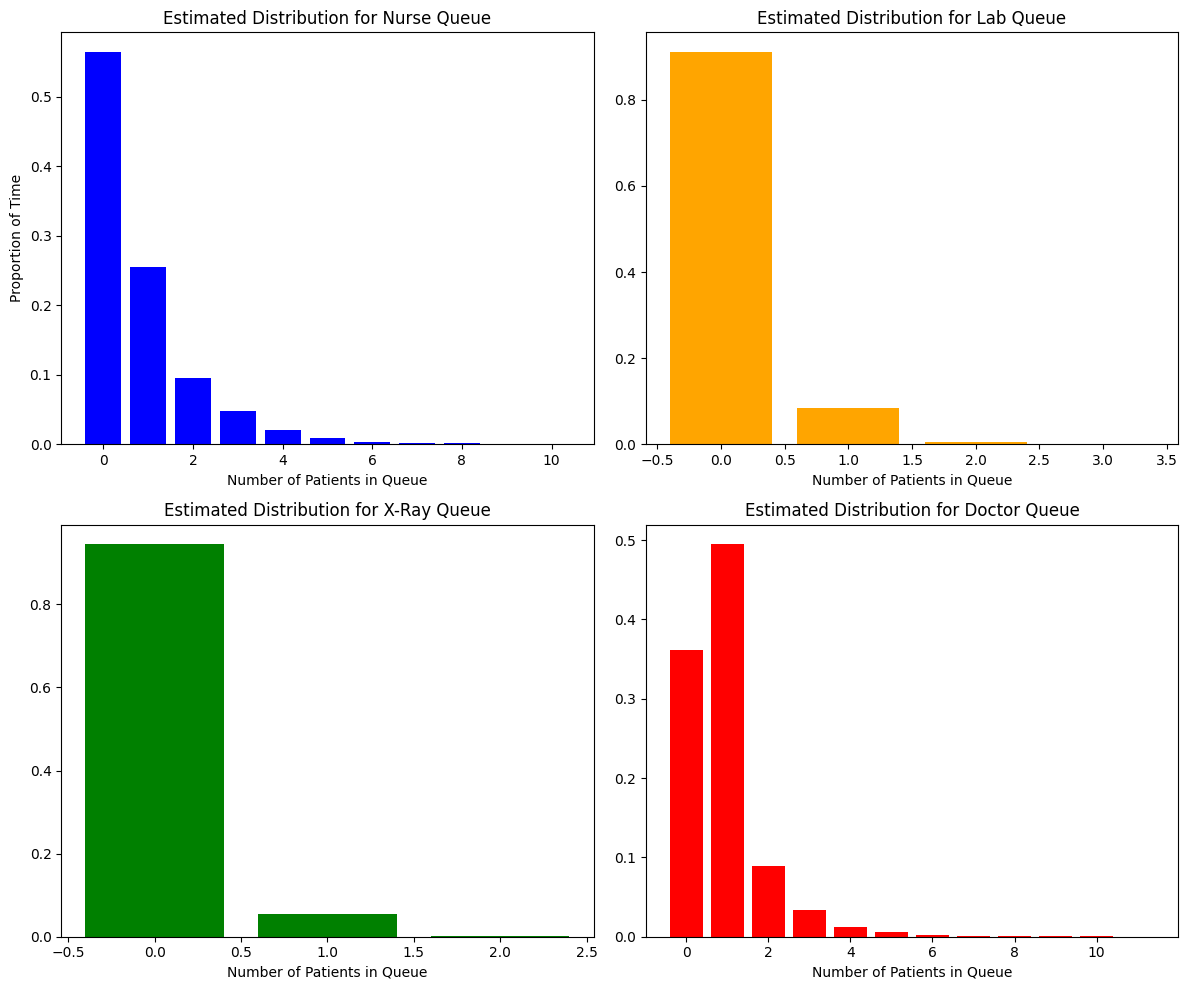

In [132]:
Q_N, Q_L, Q_X, Q_D = er_simulation()

nurse_distribution = estimate_distributions(Q_N)
lab_distribution = estimate_distributions(Q_L)
xray_distribution = estimate_distributions(Q_X)
doctor_distribution = estimate_distributions(Q_D)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].bar(nurse_distribution.keys(), nurse_distribution.values(), color='blue')
axes[0, 0].set_title('Estimated Distribution for Nurse Queue')
axes[0, 0].set_xlabel('Number of Patients in Queue')
axes[0, 0].set_ylabel('Proportion of Time')
axes[0, 1].bar(lab_distribution.keys(), lab_distribution.values(), color='orange')
axes[0, 1].set_title('Estimated Distribution for Lab Queue')
axes[0, 1].set_xlabel('Number of Patients in Queue')
axes[1, 0].bar(xray_distribution.keys(), xray_distribution.values(), color='green')
axes[1, 0].set_title('Estimated Distribution for X-Ray Queue')
axes[1, 0].set_xlabel('Number of Patients in Queue')
axes[1, 1].bar(doctor_distribution.keys(), doctor_distribution.values(), color='red')
axes[1, 1].set_title('Estimated Distribution for Doctor Queue')
axes[1, 1].set_xlabel('Number of Patients in Queue')
plt.tight_layout()

## d)
The station that creates the most congestion is the doctor, as seen in the histograms. It is the only station where the most common queue length is not 0. This makes sense, because all patients have to go to the doctor, and it is the closest to being unstable - 60/4.5 = 13.3 minutes (close to doctor rate of 12), and the patients have to wait an average of 10 minutes at the nurse first, so it can cause congestion because of this.

## e)
The average number of people at the nurse is $4.5(10/60) = 0.75$. \
The arrival rate of the lab is 30% of the departure rate of the nurse, which is $0.3(6 \ \text{people/hr}) = 1.8 \text{people/hr}$. Then the average number of people at the lab is $1.8(20/60) = 0.6$. \
The arrival rate of the xray is 20% of the departure rate of the nurse, which is $0.2(6) = 1.2 \ \text{people/hr}$. Then the average number of people at the xray is $1.2(25/60) = 0.5$. \
The arrival rate of the doctor is the sum of the arrival rates of the nurse, lab, and xray - $6 + 1.8 + 1.2 = 9$. Then the average number of people at the doctor is $9(12/60) = 1.8$. 

These values correspond exactly the behavior we'd expect from the histograms.